In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [21]:
import importlib, dataset
importlib.reload(dataset)

2.20.0


<module 'dataset' from '/Users/trba/Documents/FAKS/ML/PROJEKAT/Masinsko-ucenje-I40/dataset.py'>

In [22]:
from pathlib import Path

ROOT = Path("data/raw/Flickr2K")
train_paths = [str(p) for p in ROOT.glob("*.png")]

In [45]:
train_ds = make_sr_dataset(train_paths,128,2,16,True)

In [46]:

img = load_image(train_paths[0])
print(img.shape, img.dtype)

(1452, 2040, 3) <dtype: 'float32'>


In [25]:
lr, hr = next(iter(train_ds))

print("LR shape:", lr.shape)
print("HR shape:", hr.shape)
print("LR dtype:", lr.dtype)
print("HR dtype:", hr.dtype)

print("LR min/max:", float(tf.reduce_min(lr)), float(tf.reduce_max(lr)))
print("HR min/max:", float(tf.reduce_min(hr)), float(tf.reduce_max(hr)))

LR shape: (16, 64, 64, 3)
HR shape: (16, 128, 128, 3)
LR dtype: <dtype: 'float32'>
HR dtype: <dtype: 'float32'>
LR min/max: 0.0 1.0
HR min/max: 0.0 1.0


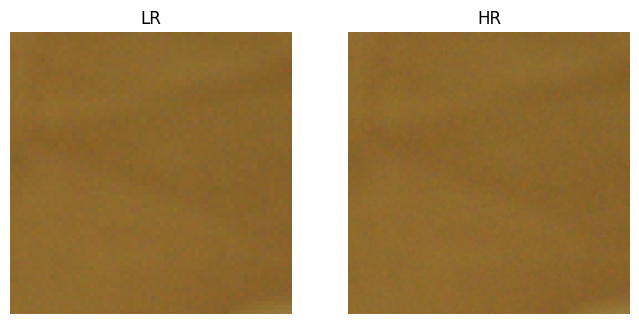

In [26]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(lr[0])
plt.title("LR")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hr[0])
plt.title("HR")
plt.axis("off")

plt.show()

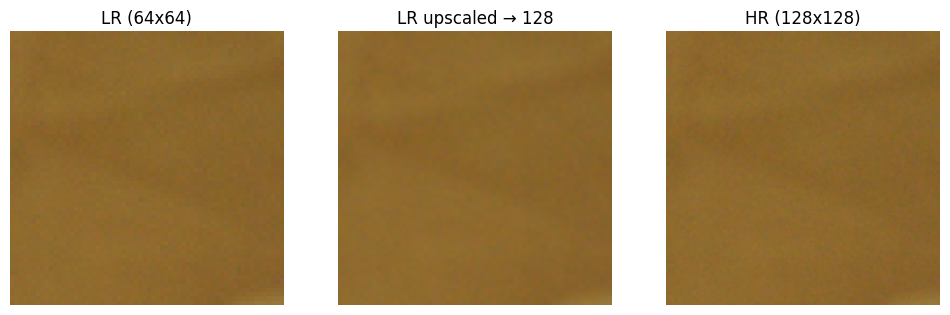

In [44]:
lr0, hr0 = lr[0], hr[0]
lr_up = tf.image.resize(lr0, (128, 128), method="bicubic")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(lr0);    plt.title("LR (64x64)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(lr_up);  plt.title("LR upscaled → 128"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hr0);    plt.title("HR (128x128)"); plt.axis("off")
plt.show()

In [35]:
diff = tf.abs(hr0 - lr_up)
print("Mean abs diff:", float(tf.reduce_mean(diff)))
print("Max abs diff:", float(tf.reduce_max(diff)))

Mean abs diff: 0.00467896880581975
Max abs diff: 0.031550467014312744


2026-03-04 13:59:49.237372: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.049558748..1.0279719].


Best score: 0.05867505073547363


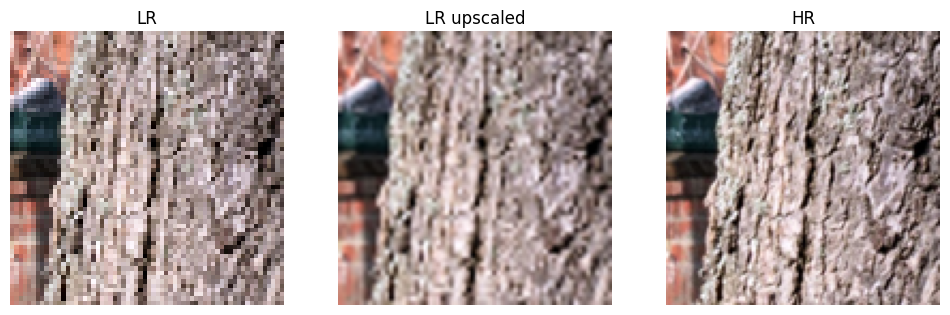

In [37]:
best = None
best_score = -1

for lr_b, hr_b in train_ds.take(10):  # 10 batch-eva
    lr0, hr0 = lr_b[0], hr_b[0]
    lr_up = tf.image.resize(lr0, (128,128), method="bicubic")
    score = float(tf.reduce_mean(tf.abs(hr0 - lr_up)))
    if score > best_score:
        best_score = score
        best = (lr0, lr_up, hr0)

print("Best score:", best_score)

lr0, lr_up, hr0 = best
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(lr0);   plt.title("LR"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(lr_up); plt.title("LR upscaled"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hr0);   plt.title("HR"); plt.axis("off")
plt.show()